In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("smartcart_customers.csv")
df = pd.read_csv("smartcart_customers.csv")


# data Preprocessing

## 1. Handling missing values

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

## 2. Feature Engineering

In [6]:
# handling birth years
df["Age"] = 2026- df["Year_Birth"]

# handling join dates_year

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customers_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,247,2,9,3,4,5,0,0,59,381
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,7,8,2,5,7,0,0,80,19
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,24,1,2,3,13,6,0,0,45,155
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,61,2,6,5,10,3,0,0,70,156


In [7]:
# Combine some of the features

# Combine all spendings
df["Total_spendings"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# combine kids and teenagers at home columns

df["children"] = df["Teenhome"] + df["Kidhome"]

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spendings,children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,59,381,1341,1
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,2,5,7,0,0,80,19,444,3
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,0,45,155,1241,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,70,156,843,1


In [8]:
## df["Education"].value_counts()

# Replace five categories to three 

df["Education"] = df["Education"].replace({
    "Graduation":"Graduate",
    "PhD": "PostGraduate", "Master" : "PostGraduate",
    "2n Cycle":"UnderGraduate","Basic":"UnderGraduate"
})
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [9]:
df.columns


df["Live_with"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone",
    "YOLO":"Alone"
})

    

In [10]:
df["Live_with"].value_counts()

Live_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [14]:
# Removing unneccessary features

cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","MntWines","MntFruits","MntMeatProducts",
        "MntFishProducts","MntSweetProducts","MntGoldProds","Dt_Customer"]

df_cleaned = df.drop(columns=cols)
df_cleaned.shape

(2240, 15)

# Detecting Outliers

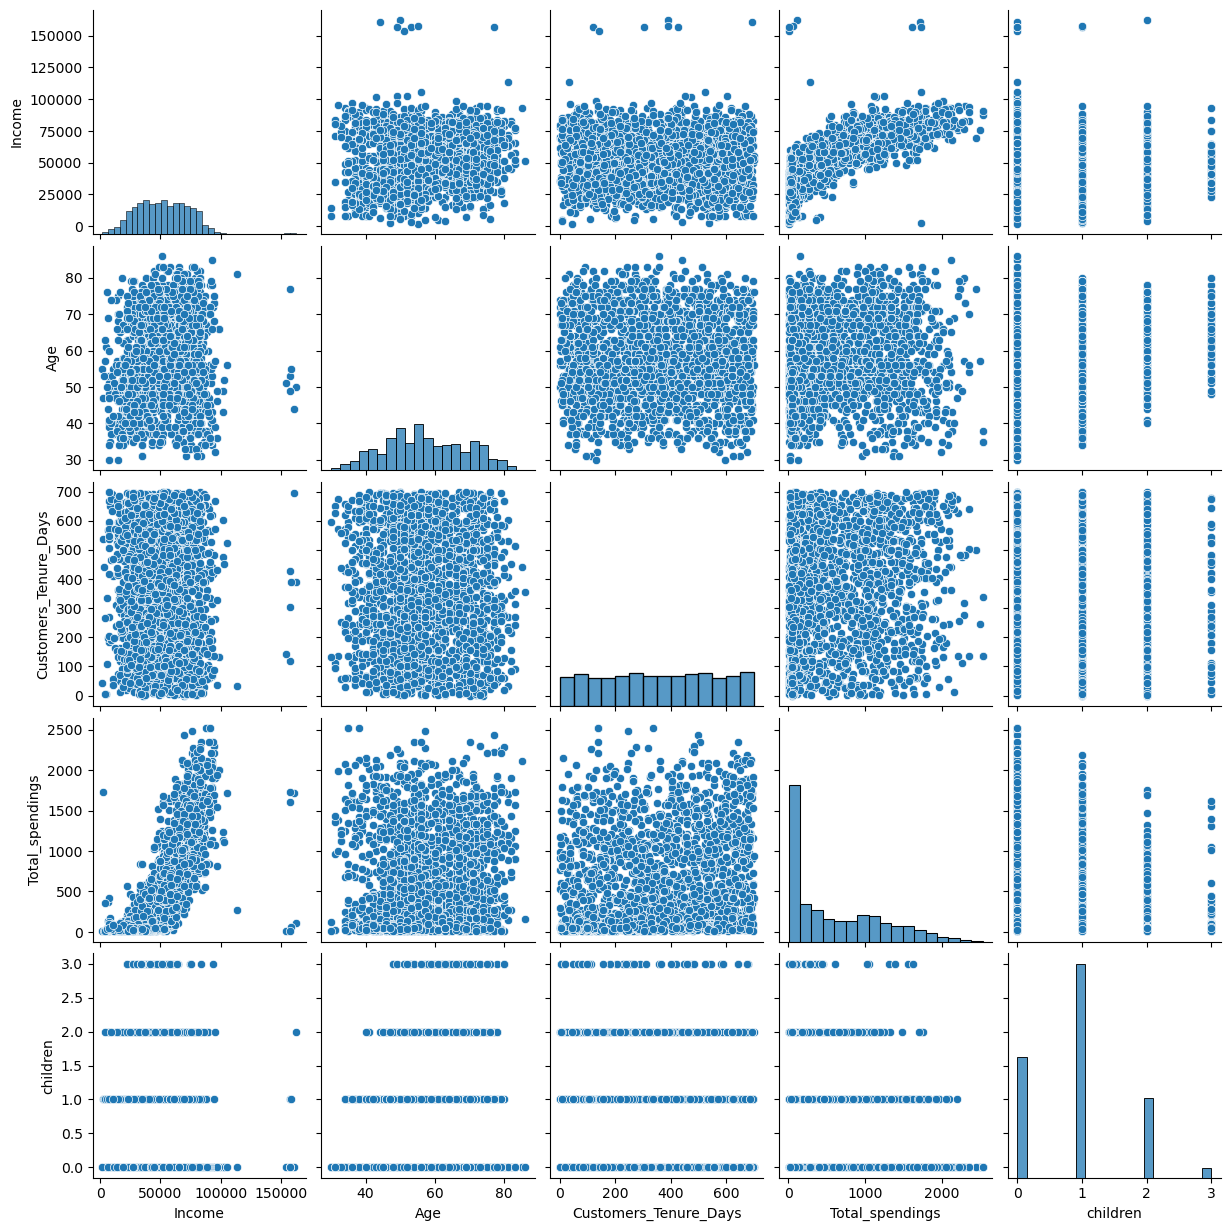

In [17]:
cols = ["Income","Age","Customers_Tenure_Days","Total_spendings","children"]

sns.pairplot(df_cleaned[cols])

In [20]:
# after detecting outliers
l1 = len(df_cleaned)

df_cleaned = df_cleaned[df_cleaned["Age"] < 90]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600000]

l2 = len(df_cleaned)

print("Length before removing outliers: ",l1)
print("Length after removing outliers: " ,l2)

Length before removing outliers:  2236
Length after removing outliers:  2236


# Heatmap -> Corelation

<Axes: >

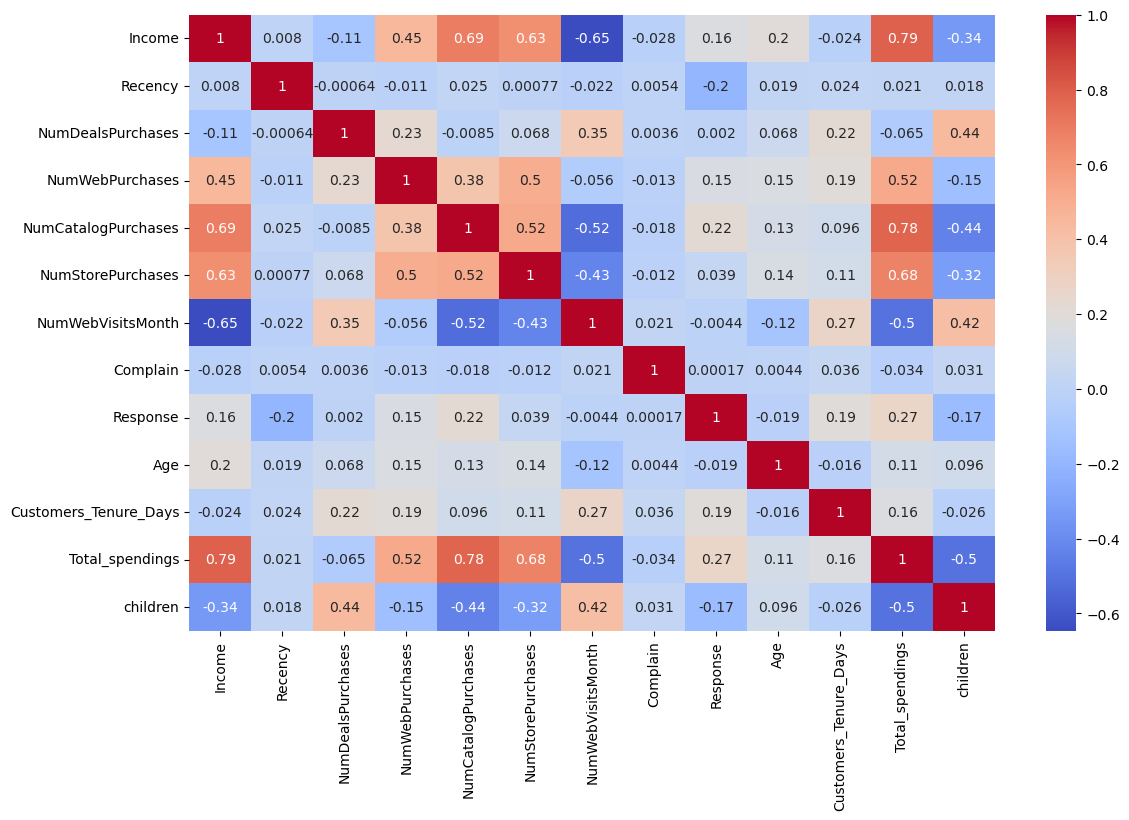

In [18]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(13,8))

sns.heatmap(
    corr,
    annot = True,
    cmap="coolwarm"
)



# One Hot Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education","Live_with"]
encoded = ohe.fit_transform(df_cleaned[cat_cols])

encoded_df = pd.DataFrame(encoded.toarray(),columns = ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [25]:
# Asiign in def_cleaned

df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),encoded_df],axis=1)

# Scaling Dataset

In [27]:
from sklearn.preprocessing import StandardScaler

X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

array([[ 0.2885133 ,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.26243786, -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91799157, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.23446459,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80737157, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04237444, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualize the data

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2,random_state=42)

pca_df = pca.fit_transform(X_scaled)

<Axes: >

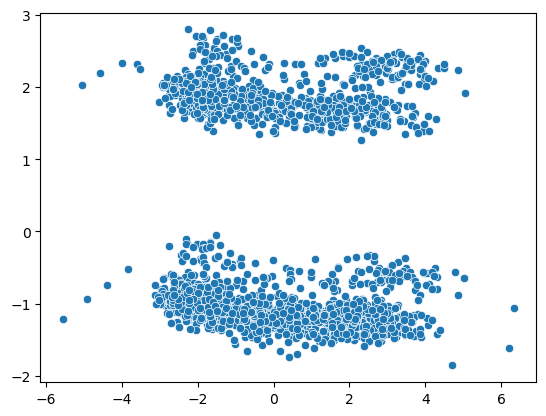

In [30]:
sns.scatterplot(x = pca_df[:,0],y=pca_df[:,1])

In [31]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437])

In [34]:
# visulaize data in 3d

pca3 = PCA(n_components=3,random_state=42)

pca3_df = pca3.fit_transform(X_scaled)

pca3.explained_variance_ratio_

# pca7 = PCA(n_components=7,random_state=42)

# pca7_df = pca7.fit_transform(X_scaled)

# pca7.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

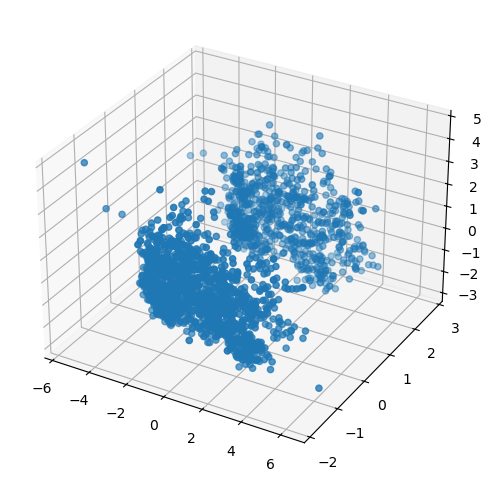

In [35]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(pca3_df[:,0],pca3_df[:,1],pca3_df[:,2])


# find best K value

## 1. By elbow method

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Best K value using elbow method is: 4


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


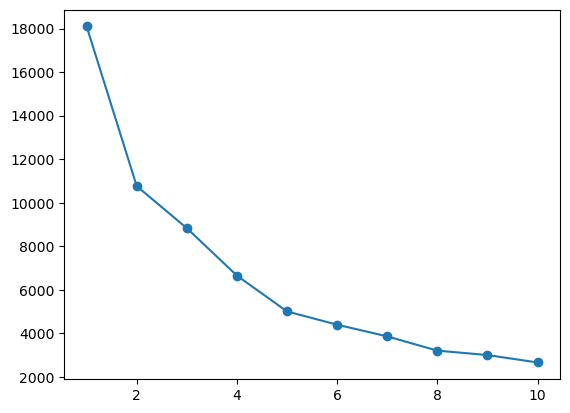

In [36]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i,random_state=42)
    model.fit_predict(pca3_df)
    wcss.append(model.inertia_)

knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
best_k = knee.elbow

print("Best K value using elbow method is:",best_k)

plt.plot(range(1,11),wcss,marker="o")

## 2. By silhoutte method

In [37]:
from sklearn.metrics import silhouette_score

scores = []

for i in range(2,11):
    model = KMeans(n_clusters=i,random_state=42)
    labels = model.fit_predict(pca3_df)
    scores.append(silhouette_score(pca3_df,labels))

scores

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

[0.37156531690760225,
 0.30775183737963807,
 0.3581062881334625,
 0.4000022648128649,
 0.3986949869973479,
 0.4005087799370214,
 0.4051058892755933,
 0.4038311527493008,
 0.3917941377172572]

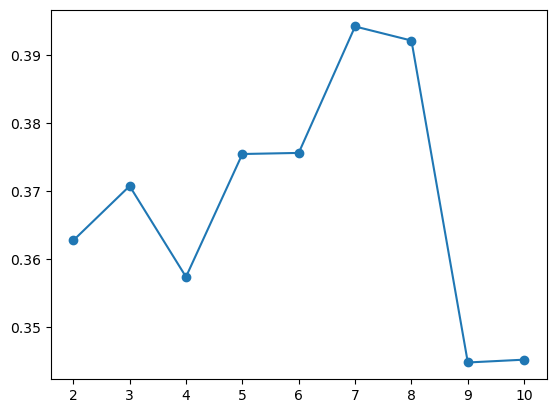

In [57]:
plt.plot(range(2,11),scores,marker="o")

# Clustering

## 1. Kmeans

In [38]:
kmeans = KMeans(n_clusters=4,random_state=42)

labels = kmeans.fit_predict(pca3_df)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


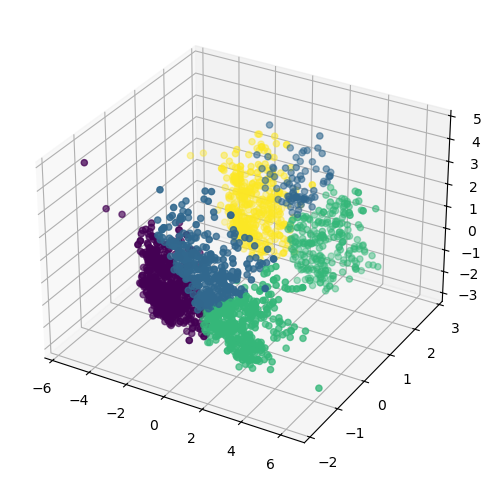

In [39]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(pca3_df[:,0],pca3_df[:,1],pca3_df[:,2],c=labels)

## 2. Agglomerative clustering

In [40]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)

labels_agg = agg.fit_predict(pca3_df)
labels_agg

array([3, 2, 1, ..., 3, 1, 0], shape=(2236,))

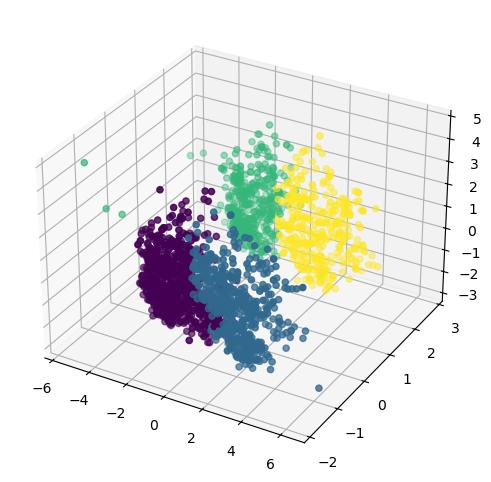

In [41]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(pca3_df[:,0],pca3_df[:,1],pca3_df[:,2],c=labels_agg)

# Analyze the clusters

In [42]:
df_cleaned["clusters"] = labels_agg
df_cleaned["clusters"].value_counts()

clusters
0    905
1    534
2    444
3    353
Name: count, dtype: int64

<Axes: xlabel='Total_spendings', ylabel='Income'>

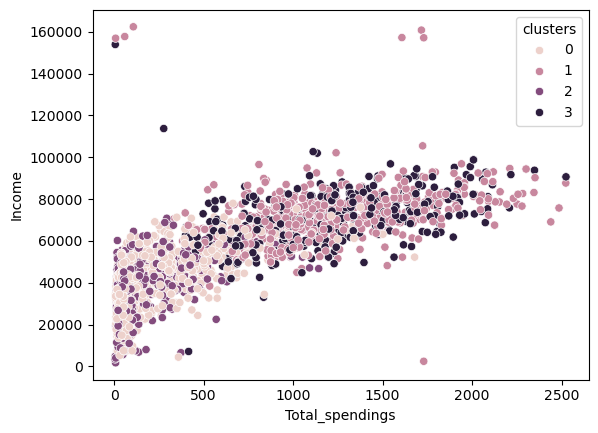

In [45]:
# check corealtion of income and total spendings

sns.scatterplot(x=df_cleaned["Total_spendings"],y=df_cleaned["Income"],hue = df_cleaned["clusters"])

In [57]:
X["clusters"] = labels_agg

clusters_summary = X.groupby("clusters").mean()
clusters_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spendings,children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Live_with_Alone,Live_with_Partner
clusters,,,,,,,,,,,,,,,,,,
0,39690.146424,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72814.930722,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36973.792251,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70730.038963,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000
